In [1]:
!pip install sif_parser

Defaulting to user installation because normal site-packages is not writeable


In [20]:
import sif_parser
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Source

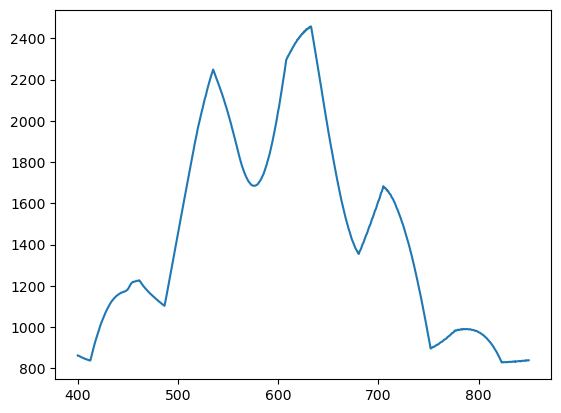

In [21]:
source, info = sif_parser.np_open('LF_spectrum.sif')
# Fix for weird behaviour for calculating wls due to stich
info['DetectorDimensions'] = (info['size'][0], info['DetectorDimensions'][1])
wavelengths = sif_parser.utils.extract_calibration(info)
info
int_source = source[0].mean(axis=0)
plt.plot(wavelengths, int_source)

# Point 1

In [22]:
data, info = sif_parser.np_open('10sec_pt1.sif')
source, _ = sif_parser.np_open('LF_spectrum.sif')
# Fix for weird behaviour for calculating wls due to stich
info['DetectorDimensions'] = (info['size'][0], info['DetectorDimensions'][1])

In [23]:
wavelengths = sif_parser.utils.extract_calibration(info)

In [24]:
info

OrderedDict([('SifVersion', 65567),
             ('ExperimentTime', 1688675678),
             ('DetectorTemperature', -999.0),
             ('ExposureTime', 10.0),
             ('CycleTime', 10.1155),
             ('AccumulatedCycleTime', 10.1155),
             ('AccumulatedCycles', 1),
             ('StackCycleTime', 10.1155),
             ('PixelReadoutTime', 3.33333e-07),
             ('GainDAC', 0.0),
             ('DetectorType', 'DU970P_BVF \n'),
             ('DetectorDimensions', (3520, 200)),
             ('OriginalFilename',
              b'C:\\Users\\ha24428\\Documents\\20230706_sample1\\10sec_pt1.sif'),
             ('ShutterTime', (0.0, 0.0)),
             ('spectrograph', '999'),
             ('SifCalbVersion', 65540),
             ('Calibration_data',
              [399.872131347656, 0.127877235412598, 0.0, 0.0]),
             ('FrameAxis', b'Wavelength'),
             ('DataType', b'Counts'),
             ('ImageAxis', b'Pixel number'),
             ('NumberOfFrames', 1

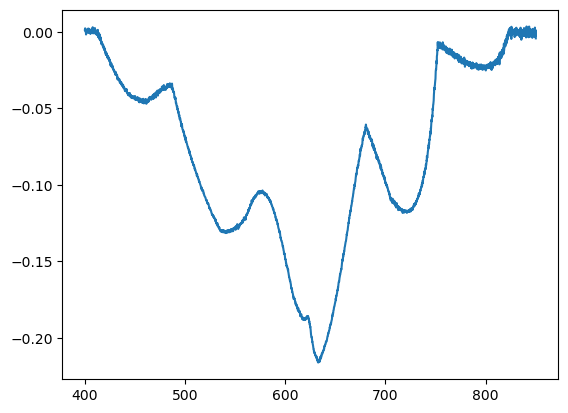

In [25]:
int_source = source[0].mean(axis=0)
spectrum = data[0, 98:103, :].mean(axis=0)
background = data[0, 0:40,:].mean(axis=0)
plt.plot(wavelengths,(spectrum-background)/int_source)